In [130]:
import qutip as q
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import (AutoMinorLocator)
import numpy as np
%matplotlib inline

For this exercise, we will be using Qutip and its ability to extract the energy levels from a provided Hamiltonian.

To begin, we will examine the Hamiltonian of a standard LC oscillator. This is derived in 101.4.

$\hat{H}=\frac{\hat{Q}^2}{2C} + \frac{\hat{\Phi}^2}{2L}$

This can be rearranged to use creation and annihilation operators, which will allow us to translate this into Qutip code more easily.

$\hat{a}=\frac{1}{\sqrt{\hbar\omega}}(\frac{\hat{\Phi}}{\sqrt{2L}}-i\frac{\hat{Q}}{\sqrt{2C}})\\
\hat{H}=\hbar\omega(\hat{a}^\dagger\hat{a} + \frac{1}{2})$

These operators, $\hat{a}$ and $\hat{a}^\dagger$ represent lowering or increasing the energy state of a quantum system by one. From this, we can deduce that

$E_n=\hbar\omega(n+\frac{1}{2})$

This is what we would expect, as an LC oscillator is a form of harmonic oscillator, with the capacitor energy being viewed as "kinetic energy" and the inductor energy viewed as "potential energy". Thus, we can see clearly that we will have evenly spaced energy levels, spaced by $\hbar\omega$. However, say you are not convinced! Allow us to use Qutip to confirm what we know.

In [131]:
"""
The Hamiltonian of an LC Oscillator
"""
def lc_oscillator(w, N=10):
    H = w * (q.create(N) * q.destroy(N)  + 0.5)

    return q.Qobj(H)

This is the Hamiltonian for an LC oscillator. We include two parameters, $w$ and $N$. $w$ is the frequency of the oscillator (which in the case of this LC oscillator is equal to $\frac{1}{\sqrt{LC}}$) while $N$ is the number of energy states we are choosing to consider. 10 will generally be a good estimate to give us an idea of how a system behaves, but this may be tweaked to your liking. Finally, the functions ```q.create``` and ```q.destroy``` are functions provided by Qutip which allow us the declare annihilation and creation matrices. Below, you can observe what these matrices actually look like.

In [132]:
print(f"The annihilator operator for 4 energy levels, a:\n\n{q.destroy(4)}")
print(f"\n\nThe creation operator for 4 energy levels, a dagger:\n\n{q.create(4)}")

The annihilator operator for 4 energy levels, a:

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dia, isherm=False
Qobj data =
[[0.         1.         0.         0.        ]
 [0.         0.         1.41421356 0.        ]
 [0.         0.         0.         1.73205081]
 [0.         0.         0.         0.        ]]


The creation operator for 4 energy levels, a dagger:

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dia, isherm=False
Qobj data =
[[0.         0.         0.         0.        ]
 [1.         0.         0.         0.        ]
 [0.         1.41421356 0.         0.        ]
 [0.         0.         1.73205081 0.        ]]


As one final note, you may notice the omission of $\hbar$ in the above code. For ease of viewing the results, we will assume our energy levels to be in units of $\hbar$.

In [133]:
"""
Plots a set of provided energy levels
"""
def plot_energies(energies):
    fig, ax = plt.subplots(figsize=(3,4.5))
    ax.scatter([1]*len(energies), energies, marker="_", s=20000, linewidth=2, zorder=3)
    ax.set_ylabel(r'Energies ($\hbar$)', fontsize=14)
    ax.grid(linestyle='-', linewidth=1)
    ax.set_xticks([])
    ax.yaxis.set_minor_locator(AutoMinorLocator())

    return fig, ax

We define this function, ```plot_energies```, to give us a visual representation of these energy levels. We can extract the energy levels from the Hamiltonian using Qutip. This will give us a NumPy array of length N containing the energy levels! This can be plotted using our above function. Try playing around with the number of energy levels and the frequency of the system.

20 energy levels for an LC Oscillator of frequency 40:
[ 20.  60. 100. 140. 180. 220. 260. 300. 340. 380. 420. 460. 500. 540.
 580. 620. 660. 700. 740. 780.]


(<Figure size 300x450 with 1 Axes>, <Axes: ylabel='Energies ($\\hbar$)'>)

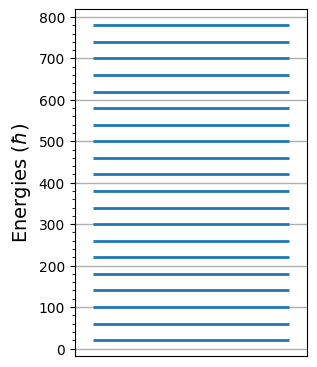

In [134]:
w = 40
N = 20

energies = (np.array(lc_oscillator(w, N).eigenenergies()))

print(f"{N} energy levels for an LC Oscillator of frequency {w}:\n{energies}")

plot_energies(energies)

Another helpful plot will show us the *differences* between energy levels. In engineering superconducting qubits, we seek a system which has a different energy gap between the first two energy levels so we can properly control the state of our system and know what transition we may choose to affect.

In [135]:
"""
Plots the differences from a set of energies levels
"""
def plot_differences(energies):

    fig, ax = plt.subplots(figsize=(3,4.5))

    # for n in range(len(energies[0,:])):
    #     axes[1].plot(ng_vec, (energies[:,n]-energies[:,0])/(energies[:,1]-energies[:,0]))
    #ax.plot(ng_vec, (energies[:,2]-energies[:,1]))

    diffs = np.delete(energies, 0) - np.delete(energies, len(energies)-1)

    colors = cm.rainbow(np.linspace(0, 1, len(diffs)))
    for diff, col in zip(diffs, colors):
        ax.scatter([1], diff, marker="_", s=20000, linewidth=2, zorder=3, color=col)
    ax.set_ylabel(r'Energy Differences ($\hbar$)', fontsize=14)
    ax.grid(linestyle='-', linewidth=1)
    ax.set_xticks([])
    ax.yaxis.set_minor_locator(AutoMinorLocator())

    return fig, ax

(<Figure size 300x450 with 1 Axes>,
 <Axes: ylabel='Energy Differences ($\\hbar$)'>)

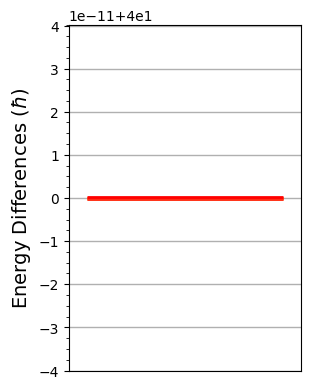

In [136]:
plot_differences(energies)

As we expect, all of the energy levels have the same differences from each other! This demonstrates how a simple LC circuit is unfit to create a qubit. We must modify our circuit to create variations in the energy levels. To do this, we replace the inductor in our circuit with a **Josephson Junction**. This is the **transmon qubit**. This provides us with the Hamiltonian:

$\hat{H}=4E_C\hat{n}^2-E_J\cos(\hat{\phi})$

where $E_c = \frac{e^2}{2C_\Sigma}$, $C_\Sigma=C_s+C_J$, and $E_J=\frac{I_c\Phi_0}{2\pi}$. $\hat{n}$ and $\hat{\phi}$ are the reduced charge and flux operators, $e$ is the charge of an electron, $C_\Sigma$ is the total capacitance, $C_s$ is the shunt capacitance (the capacitance of our original capacitor), $C_J$ is the self-capacitance of the Josephson Junction, and $I_C$ is the critical current of the Josephson Junction. The first term represents the capacitative effects of the shunt capacitor and the junction while the second term representings tunnelings across the junction. This is detailed in greater depth in the text. 

This is implemented in Qutip below.

In [137]:
"""
The Hamiltonian of an transmon qubit
"""
# def transmon(wq, Ec, N):
#     H = wq * (q.create(N) * q.destroy(N)) - (Ec / 2) * (q.create(N) * q.create(N) * q.destroy(N) * q.destroy(N))

#     return q.Qobj(H)

def transmon(Ec, Ej, N):
    H = 4 * Ec * (q.charge(N)**2).full() + 0.5 * Ej * (np.diag(-np.ones(2*N), 1) + np.diag(-np.ones(2*N), -1))

    return q.Qobj(H)

Let us view inspect its energy level structure.

In [383]:
"""
Plots energy levels and differences
"""
def plot_energy_stuff(energies, y_range=(-2, 30)):

    fig, ax = plt.subplots(1,2, figsize=(12,6))

    ax[0].scatter([1]*len(energies), energies, marker="_", s=20000, linewidth=2, zorder=3)
    ax[0].set_ylabel(r'Energies ($\hbar$)', fontsize=14)
    ax[0].grid(linestyle='-', linewidth=1)
    ax[0].set_xticks([])
    ax[0].yaxis.set_minor_locator(AutoMinorLocator())
    ax[0].set_ylim(y_range)
    for i in range(len(energies)):
        ax[0].annotate(fr"|{i}$\rangle$", xy=(1.032 if (i % 2 == 0) else 1.028, energies[i]))

    diffs = np.delete(energies, 0) - np.delete(energies, len(energies)-1)

    colors = cm.rainbow(np.linspace(0, 1, len(diffs)))
    for diff, col in zip(diffs, colors):
        ax[1].scatter([1], diff, marker="_", s=20000, linewidth=2, zorder=3, color=col)
    ax[1].set_ylabel(r'Energy Differences ($\hbar$)', fontsize=14)
    ax[1].grid(linestyle='-', linewidth=1)
    for i in range(len(diffs)):
        ax[1].annotate(fr"$|{i}\rangle$ to $|{i+1}\rangle$", xy=(1.028, diffs[i]))
    ax[1].yaxis.set_minor_locator(AutoMinorLocator())

    return fig, ax

Energy levels for an transmon qubit with Ec = 1 and Ej = 1:
[-1.21765545e-01  3.97918922e+00  4.10090060e+00  1.60083105e+01
  1.60083646e+01  3.60035717e+01  3.60035717e+01  6.40019842e+01
  6.40019842e+01  1.00001263e+02  1.00001263e+02  1.44000874e+02
  1.44000874e+02  1.96000641e+02  1.96000641e+02  2.56000490e+02
  2.56000490e+02  3.24000387e+02  3.24000387e+02  4.00003289e+02
  4.00003289e+02]


(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: ylabel='Energies ($\\hbar$)'>,
        <Axes: ylabel='Energy Differences ($\\hbar$)'>], dtype=object))

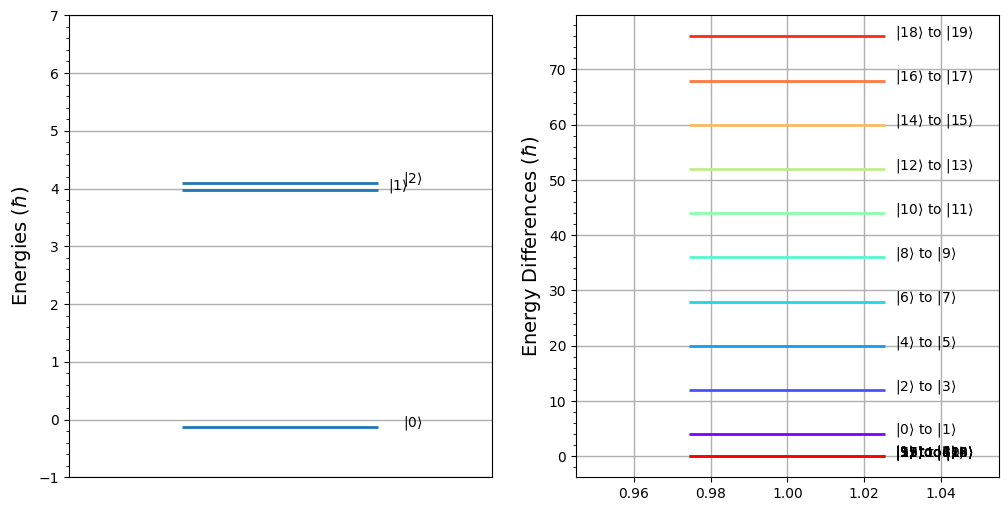

In [384]:
Ec = 1
Ej = 1
N = 10

energies = (np.array(transmon(Ec, Ej, N).eigenenergies()))

print(f"Energy levels for an transmon qubit with Ec = {Ec} and Ej = {Ej}:\n{energies}")

plot_energy_stuff(energies, (-1, 7))

Our circuit demonstrates aharmonicity now! The differences between energy levels are now unique and can be individually targeted. Since we can avoid higher energies levels and since often $|E_c|<<w_q$, this can be treated now as a quantum two-level system with

$\hat{H}=\omega_q\frac{\sigma_z}{2}$

Remember this is just a simplification for the purposes of superconducting quantum computing; the higher energies levels still physically exist even if we do not use them computationally.

In [140]:
def simple_transmon(wq):
    H = wq * 0.5 * q.sigmaz()
    
    return q.Qobj(H)

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: ylabel='Energies ($\\hbar$)'>,
        <Axes: ylabel='Energy Differences ($\\hbar$)'>], dtype=object))

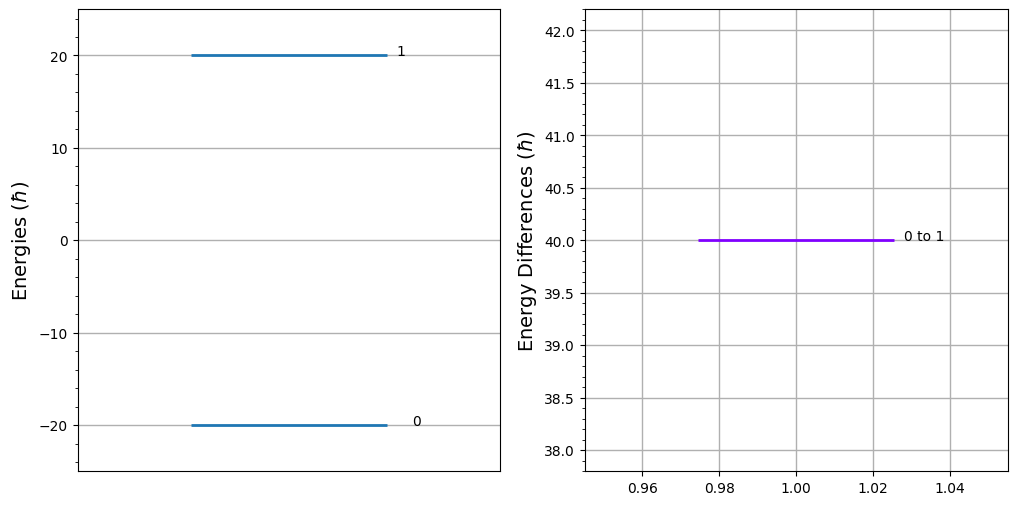

In [191]:
wq = 40

energies = np.array(simple_transmon(wq).eigenenergies())

plot_energy_stuff(energies, (-25, 25))

Qubits are subject to various forms of noise. One we will focus on in particular here is *charge noise* from the environment. This is an offset charge occuring from outside the qubit system which influences the energy level structure. This "effective offset charge" is often denoted with $n_g$. Superconducting qubits are sensitive to this noise, however, the transmon qubit was design to reduce this sensitivity. We can model a transmon qubit experiencing charge noise as so:

$\hat{H}=4E_C(\hat{n}-n_g)^2-E_J\cos(\hat{\phi})$

To model this Hamiltonian, we will modify our first transmon Hamiltonian to accomadate this noise.

In [145]:
def transmon_ng(Ec, Ej, ng, N):
    H = 4 * Ec * ((q.charge(N)-ng)**2).full() + 0.5 * Ej * (np.diag(-np.ones(2*N), 1) + np.diag(-np.ones(2*N), -1))

    return q.Qobj(H)

To model this qubit, we will plot the energy levels and the energy level differences as a function of $n_g$.

In [389]:
def plot_energy_as_function(x, energies, y_range=(-2, 12), x_axis="", levels = 2):

    fig, ax = plt.subplots(1,2, figsize=(12,6))

    for i in range(len(energies[0])): # for each energy level, plot its curve
        ax[0].plot(x, energies[:, i], zorder=3)
    ax[0].set_ylabel(r'Energies ($\hbar$)', fontsize=14)
    ax[0].set_xlabel(x_axis, fontsize=14)
    ax[0].grid(linestyle='-', linewidth=1)
    ax[0].set_ylim(y_range)
    for i in range(len(energies[0])):
        ax[0].annotate(fr"$|{i}\rangle$", xy=(0.3, energies[len(energies[:,i])//2][i]))
    ax[0].yaxis.set_minor_locator(AutoMinorLocator())

    diffs = np.array([(np.delete(energies[i], 0) - np.delete(energies[i], len(energies[i])-1)) for i in range(len(energies[:,0]))])
    for i in range(levels):
        ax[1].plot(x, diffs[:,i], zorder=3, label=fr"$|{i}\rangle\rightarrow|{i+1}\rangle$")
    ax[1].set_ylabel(r'Energy Differences ($\hbar$)', fontsize=14)
    ax[1].set_xlabel(x_axis, fontsize=14)
    ax[1].grid(linestyle='-', linewidth=1)
    for i in range(levels):
        ax[1].annotate(fr"$|{i}\rangle$ to $|{i+1}\rangle$", xy=(0, diffs[len(diffs[:,i])//2][i]))
    ax[1].yaxis.set_minor_locator(AutoMinorLocator())
    ax[1].legend()

    return fig, ax

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: xlabel='$n_g$', ylabel='Energies ($\\hbar$)'>,
        <Axes: xlabel='$n_g$', ylabel='Energy Differences ($\\hbar$)'>],
       dtype=object))

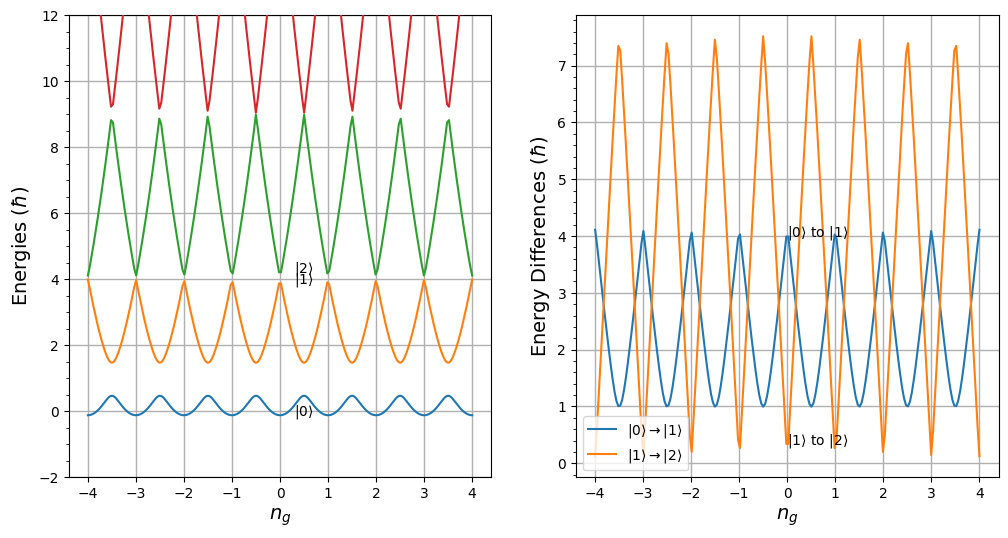

In [392]:
Ec = 1
Ej = 1
all_ng = np.linspace(-4, 4, 200)
N = 5

energies = np.array([transmon_ng(Ec, Ej, ng, N).eigenenergies() for ng in all_ng])

plot_energy_as_function(all_ng, energies, x_axis=r"$n_g$")

For this qubit, $E_C = E_J$.  Transmon qubits operate in the regime $E_C << E_J$. Let's try that now.

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: xlabel='$n_g$', ylabel='Energies ($\\hbar$)'>,
        <Axes: xlabel='$n_g$', ylabel='Energy Differences ($\\hbar$)'>],
       dtype=object))

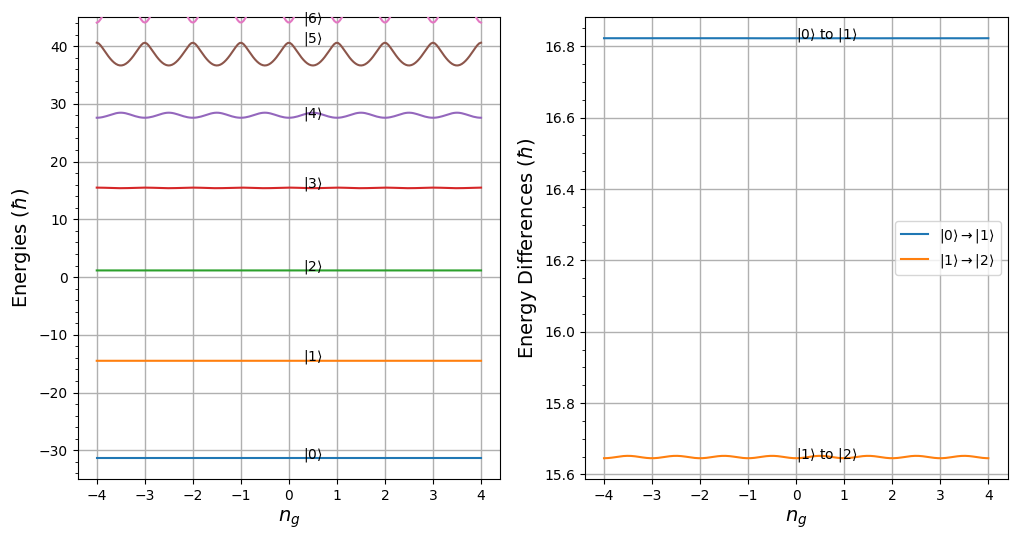

In [393]:
Ec = 1
Ej = 40
all_ng = np.linspace(-4, 4, 200)
N = 10

energies = np.array([transmon_ng(Ec, Ej, ng, N).eigenenergies() for ng in all_ng])

plot_energy_as_function(all_ng, energies, x_axis=r"$n_g$", y_range=(-35, 45))

Increasing the ratio of $E_J/E_C$ has reduced the fluctuations at the lowest energy levels due to charge noise!

To further control transmon qubit systems, we replace our Josephson Junction with a loop containing two junctions. This device is called a superconducting quantum interference device (SQUID). An external magnetic flux ($\Phi_{\text{ext}}$) may be threaded through this loop, allowing us to tune the energy by changing that external flux.

$\hat{H}=4E_c\hat{n}^2-2E_J|\cos(\varphi_{ext})|\cos(\hat{\phi})$

where $\varphi_{ext}=\frac{\pi\Phi_{\text{ext}}}{\Phi_0}$

In [207]:
def split_transmon(Ec, Ej, phi, N):
    H = 4 * Ec * (q.charge(N)**2).full() + Ej * np.abs(np.cos(phi)) * (np.diag(-np.ones(2*N), 1) + np.diag(-np.ones(2*N), -1))

    return q.Qobj(H)

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: xlabel='$\\phi_{ext}$', ylabel='Energies ($\\hbar$)'>,
        <Axes: xlabel='$\\phi_{ext}$', ylabel='Energy Differences ($\\hbar$)'>],
       dtype=object))

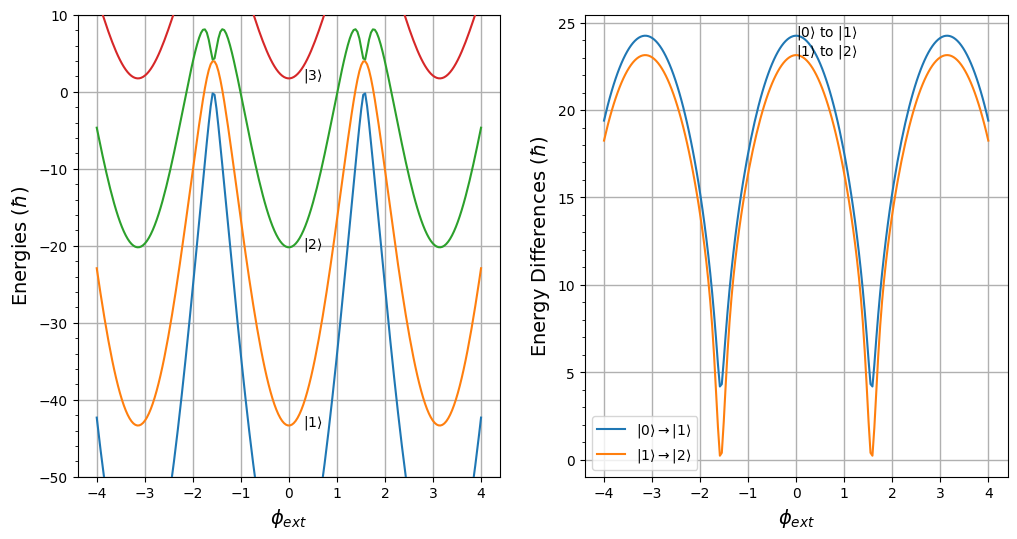

In [394]:
Ec = 1
Ej = 40
all_phi = np.linspace(-4, 4, 200)
N = 10

energies = np.array([split_transmon(Ec, Ej, phi, N).eigenenergies() for phi in all_phi])

plot_energy_as_function(all_phi, energies, x_axis=r"$\phi_{ext}$", y_range=(-50, 10))

In [183]:
def assymetric_transmon(Ec, Ej1, Ej2, phi, N):
    gamma = Ej2 / Ej1
    d = (gamma - 1) / (gamma + 1)
    H = 4 * Ec * (q.charge(N)**2).full() + (Ej1 + Ej2) * np.sqrt(np.cos(phi)**2 + (d**2)*np.sin(phi)**2) * (np.diag(-np.ones(2*N), 1) + np.diag(-np.ones(2*N), -1))

    return q.Qobj(H)

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: xlabel='$\\phi_{ext}$', ylabel='Energies ($\\hbar$)'>,
        <Axes: xlabel='$\\phi_{ext}$', ylabel='Energy Differences ($\\hbar$)'>],
       dtype=object))

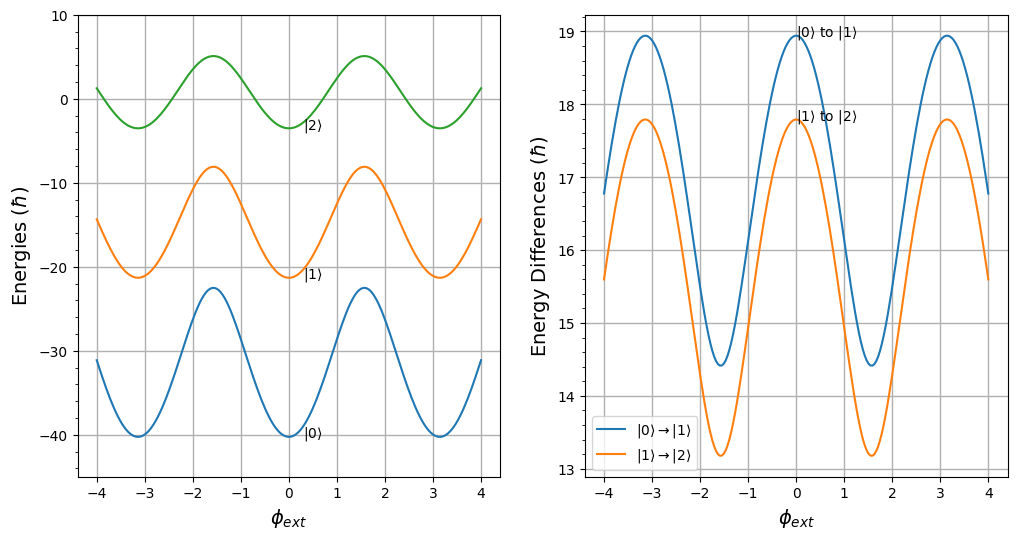

In [395]:
Ec = 1
Ej1 = 5
Ej2 = 20
all_phi = np.linspace(-4, 4, 200)
N = 10

# Gamma = 4
energies = np.array([assymetric_transmon(Ec, Ej1, Ej2, phi, N).eigenenergies() for phi in all_phi])
plot_energy_as_function(all_phi, energies, x_axis=r"$\phi_{ext}$", y_range=(-45, 10))

If $E_{J1} = E_{J2}$, this will resemble the split transmon. As $|d|=|\frac{\gamma-1}{\gamma+1}|$ approaches 1, the flux tunability goes away and we are faced with constant energy levels.

# BORDER OF OFFICIAL CONTENT

https://arxiv.org/pdf/cond-mat/0703002
file:///C:/Users/ANNA%20STEEN/Downloads/s11128-009-0101-5%20(3).pdf
https://github.com/jrjohansson/qutip-lectures/blob/master/Lecture-11-Charge-Qubits.ipynb
https://boulderschool.yale.edu/sites/default/files/files/devoret_quantum_fluct_les_houches.pdf

Future plans
- Fix some Hamiltonian/make their descriptions more clear
- Detail some time evolution/gates

In [256]:
def hamiltonian(Ec, Ej, N, phi, ng, Ej2 = 0):
    """
    Return the charge qubit hamiltonian as a Qobj instance.
    """
    # n = (Ej/(32*Ec))**0.25
   # phi = (2*Ec/Ej)**0.25
    gamma = Ej2 / Ej
    d = (gamma - 1) / (gamma + 1)

    # m = np.sqrt(8*Ec*Ej)*(np.diag(np.sqrt(np.arange(2*N)), -1)*np.diag(np.sqrt(np.arange(2*N)), 1)+0.5)
    # m = np.diag(4 * Ec * (np.arange(-N,N+1)-ng)**2) + 0.5 * Ej * (np.diag(-np.ones(2*N), 1) + 
    #                                                            np.diag(-np.ones(2*N), -1))

    m = Ec * (q.destroy(N) * q.create(N) + 0.5)
    
    return q.Qobj(m)

def transmon2(Ec, Ej, ng, N):
    H = np.diag(4 * Ec * (np.arange(-N,N+1)-ng)**2) + 0.5 * Ej * (np.diag(-np.ones(2*N), 1) + np.diag(-np.ones(2*N), -1))

    return q.Qobj(H)

def split_transmon(Ec, Ej, ng, phi, N):
    H = np.diag(4 * Ec * (np.arange(-N,N+1)-ng)**2) + Ej * np.abs(np.cos(phi)) * (np.diag(-np.ones(2*N), 1) + np.diag(-np.ones(2*N), -1))

    return q.Qobj(H)

def assymetric_transmon(Ec, Ej1, Ej2, ng, phi, N):
    gamma = Ej2 / Ej1
    d = (gamma - 1) / (gamma + 1)
    H = np.diag(4 * Ec * (np.arange(-N,N+1)-ng)**2) + (Ej1 + Ej2) * np.sqrt(np.cos(phi)**2 + (d**2)*np.sin(phi)**2) * (np.diag(-np.ones(2*N), 1) + np.diag(-np.ones(2*N), -1))

    return q.Qobj(H)

def jaynes_cummings(wr, wq, g, N): 
    a  = q.tensor(q.destroy(N), q.qeye(2))
    sm = q.tensor(q.qeye(N), q.destroy(2))

    H = wr * a.dag() * a + 0.5 * wq * q.tensor(q.qeye(N), q.sigmaz()) + g * (a.dag() * sm + a * sm.dag())
    
    return q.Qobj(H)
     

In [ ]:
    
N = 10  
Ec = 0.3  
Ej = 15
        
    
ng_vec = np.linspace(-4, 4, 200)

energies = (np.array([transmon2(Ec, Ej, 0, N).eigenenergies() for ng in ng_vec]))

# energies = (np.array([assymetric_transmon(Ec, Ej, 2*Ej, 0, ng, N).eigenenergies() for ng in ng_vec]))

plot_energies(ng_vec, energies, ymax=(20, 30))

Created by Tom Steen, 2026.

No AI was used in the creation of this notebook.